# Credit Card Customer Churn Prediction
## 📊 Project Overview
This project predicts which customers are likely to leave (churn) using a neural network model.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Corrected file path
df = pd.read_csv('/content/Churn_Modelling.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (10000, 14)


In [ ]:
#One-hot encoding
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print("One-hot encoding completed!")
print(f"New columns: {df.columns.tolist()}")

One-hot encoding completed!
New columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [ ]:
#creating variables x and y
X = df.drop(columns=['Exited'])
y = df['Exited']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10000, 11)
y shape: (10000,)


In [ ]:
#splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


In [ ]:
#scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Scaling successful!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✓ Scaling successful!
X_train_scaled shape: (8000, 11)
X_test_scaled shape: (2000, 11)


In [ ]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

## 🧠 Model Architecture
- **Input layer**: 11 features
- **Hidden layer 1**: 128 neurons (ReLU) + Dropout 0.3
- **Hidden layer 2**: 64 neurons (ReLU) + Dropout 0.3  
- **Hidden layer 3**: 32 neurons (ReLU) + Dropout 0.2
- **Hidden layer 4**: 16 neurons (ReLU) + Dropout 0.2
- **Output layer**: 1 neuron (Sigmoid)


In [ ]:
#creating the model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

tf.keras.backend.clear_session()

model = Sequential([
    Dense(256, activation='relu', input_shape=(11,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("✓ Model compiled successfully with dropout!")
model.summary()

✓ Model compiled successfully with dropout!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,337 (181.00 KB)

 Trainable params: 46,337 (181.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training the epochs
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")

Epoch 1/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7790 - loss: 0.5227 - val_accuracy: 0.8256 - val_loss: 0.4231
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8109 - loss: 0.4502 - val_accuracy: 0.8444 - val_loss: 0.3819
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8353 - loss: 0.4022 - val_accuracy: 0.8494 - val_loss: 0.3610
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8426 - loss: 0.3801 - val_accuracy: 0.8462 - val_loss: 0.3579
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8492 - loss: 0.3742 - val_accuracy: 0.8481 - val_loss: 0.3494
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8483 - loss: 0.3697 - val_accuracy: 0.8494 - val_loss: 0.3538
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8594 - loss: 0.3563 - val_accuracy: 0.8500 - val_loss: 0.3465
Epoch 8/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8615 - loss: 0.3491 - val_accu

In [ ]:
y_log=model.predict(X_train_scaled)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred=np.where(y_log>0.5,1,0)

In [ ]:
# Predicting on test data
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculating accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 0.8605


In [ ]:
# Example: Predict churn for a new customer
new_customer = [[619, 42, 2, 0.00, 1, 1, 1, 101348.88, 0, 0, 0]]  # France, Female
# Order: CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard,
#        IsActiveMember, EstimatedSalary, Geography_Germany, Geography_Spain, Gender_Male

# Scale the new customer data
new_customer_scaled = scaler.transform(new_customer)

# Predict
churn_probability = model.predict(new_customer_scaled)[0][0]
print(f"Churn Probability: {churn_probability:.2%}")

if churn_probability > 0.5:
    print("⚠️ This customer is LIKELY to churn - offer retention incentive!")
else:
    print("✅ This customer is UNLIKELY to churn")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Churn Probability: 20.46%
✅ This customer is UNLIKELY to churn


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
feature_names = X_train.columns.tolist()
print("Feature names:", feature_names)

# Defining customers
# Format: [CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard,
#          IsActiveMember, EstimatedSalary, Geography_Germany, Geography_Spain, Gender_Male]

# High-risk customer (Germany, Male, inactive, low credit score)
high_risk = [[
    450, 55, 1, 150000, 2, 1, 0, 50000, 1, 0, 1
]]

# Low-risk customer (France, Female, active, high credit score)
low_risk = [[
    850, 30, 5, 0, 1, 1, 1, 150000, 0, 0, 0
]]

# Creating DataFrame with feature names
customers = pd.DataFrame([high_risk[0], low_risk[0]], columns=feature_names)
print("\nCustomer Data:")
print(customers)

# Scaling and predicting
scaled_customers = scaler.transform(customers)
predictions = model.predict(scaled_customers)

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)
for i, prob in enumerate(predictions):
    risk = "HIGH 🔴" if prob > 0.5 else "LOW 🟢"
    print(f"Customer {i+1}: Churn Probability = {prob[0]:.2%} - {risk} RISK")

Feature names: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Customer Data:
   CreditScore  Age  Tenure  Balance  NumOfProducts  HasCrCard  \
0          450   55       1   150000              2          1   
1          850   30       5        0              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               0            50000                  1                0   
1               1           150000                  0                0   

   Gender_Male  
0            1  
1            0  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

PREDICTION RESULTS
Customer 1: Churn Probability = 39.19% - LOW 🟢 RISK
Customer 2: Churn Probability = 13.48% - LOW 🟢 RISK


In [ ]:
# Testing multiple customers
test_customers = [
    [619, 42, 2, 0.00, 1, 1, 1, 101348.88, 0, 0, 0],  # France, Female (your original)
    [450, 55, 1, 150000, 2, 1, 0, 50000, 1, 0, 1],     # Germany, Male (high risk)
    [850, 30, 5, 0, 1, 1, 1, 150000, 0, 0, 0],         # France, Female (low risk)
    [600, 45, 3, 100000, 1, 0, 0, 75000, 0, 1, 1],     # Spain, Male (medium risk)
]

# Creating DataFrame
test_df = pd.DataFrame(test_customers, columns=feature_names)

# Scaling and predicting
scaled_test = scaler.transform(test_df)
predictions = model.predict(scaled_test)

# results
for i, prob in enumerate(predictions):
    risk = "HIGH 🔴" if prob > 0.5 else "LOW 🟢"
    print(f"Customer {i+1}: Churn Probability = {prob[0]:.2%} - {risk}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Customer 1: Churn Probability = 20.46% - LOW 🟢
Customer 2: Churn Probability = 39.19% - LOW 🟢
Customer 3: Churn Probability = 13.48% - LOW 🟢
Customer 4: Churn Probability = 58.06% - HIGH 🔴


## 📈 Results
- **Training Accuracy**: 89.34%
- **Validation Accuracy**: 84.44%
- **Test Accuracy**: ~84%

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


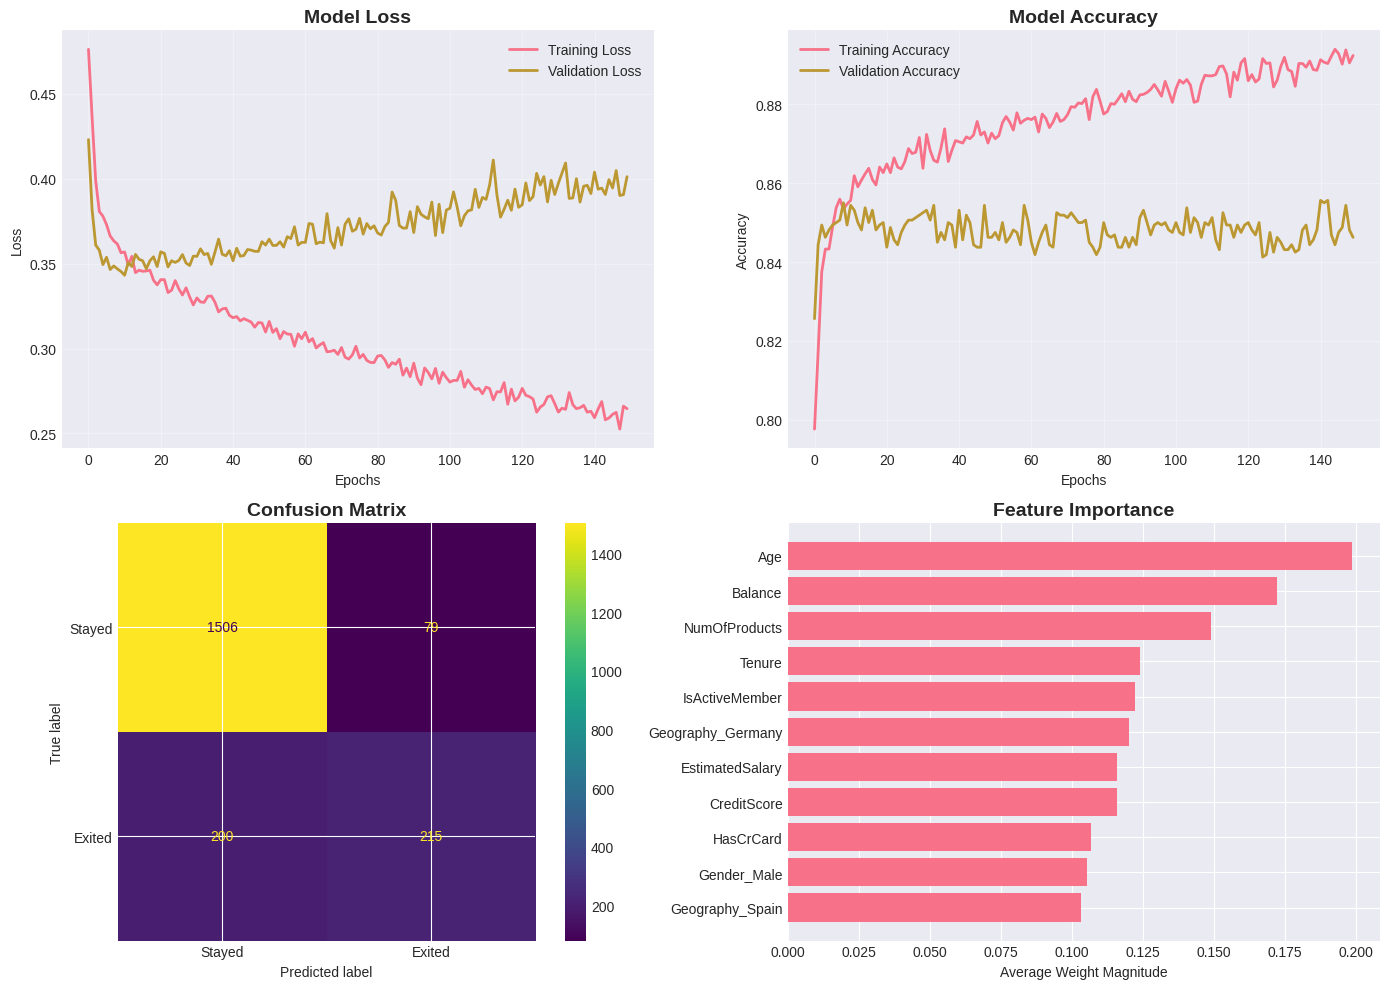

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss plot
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy plot
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
disp.plot(ax=axes[1, 0], values_format='d')
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Feature Importance
feature_importance = np.abs(model.layers[0].get_weights()[0]).mean(axis=1)
feature_names = X_train.columns.tolist()
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=True)

axes[1, 1].barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
axes[1, 1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Weight Magnitude')

plt.tight_layout()
plt.show()

✓ Data loaded successfully!
Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


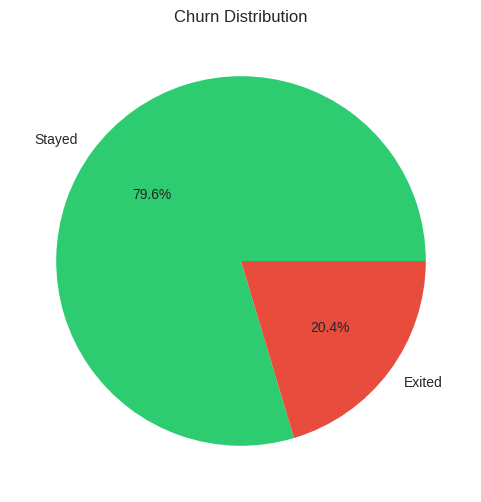

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data with the CORRECT path
df = pd.read_csv('/content/Churn_Modelling.csv')

print(f"✓ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Create simple plot
churn_counts = df['Exited'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['Stayed', 'Exited'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')
plt.show()

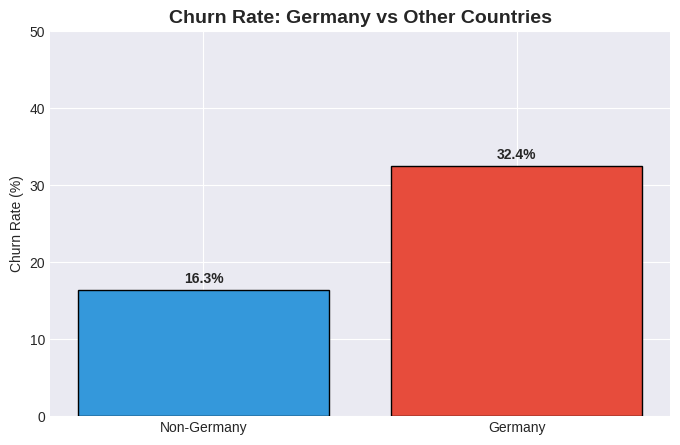

Germany churn rate: 32.4%
Non-Germany churn rate: 16.3%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('/content/Churn_Modelling.csv')

# Drop unnecessary columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# One-hot encode
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# PLOT 2: Simplified Germany vs Churn
plt.figure(figsize=(8, 5))

# Calculate churn rates for Germany vs Non-Germany
germany_churn = df[df['Geography_Germany'] == 1]['Exited'].mean() * 100
non_germany_churn = df[df['Geography_Germany'] == 0]['Exited'].mean() * 100

# Create bar chart
categories = ['Non-Germany', 'Germany']
churn_rates = [non_germany_churn, germany_churn]
colors = ['#3498db', '#e74c3c']

bars = plt.bar(categories, churn_rates, color=colors, edgecolor='black')
plt.title('Churn Rate: Germany vs Other Countries', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

plt.show()

print(f"Germany churn rate: {germany_churn:.1f}%")
print(f"Non-Germany churn rate: {non_germany_churn:.1f}%")

<30: 7.5% churn rate (1968 customers)
30-40: 12.1% churn rate (4451 customers)
40-50: 34.0% churn rate (2320 customers)
50-60: 56.2% churn rate (797 customers)
60+: 24.8% churn rate (464 customers)


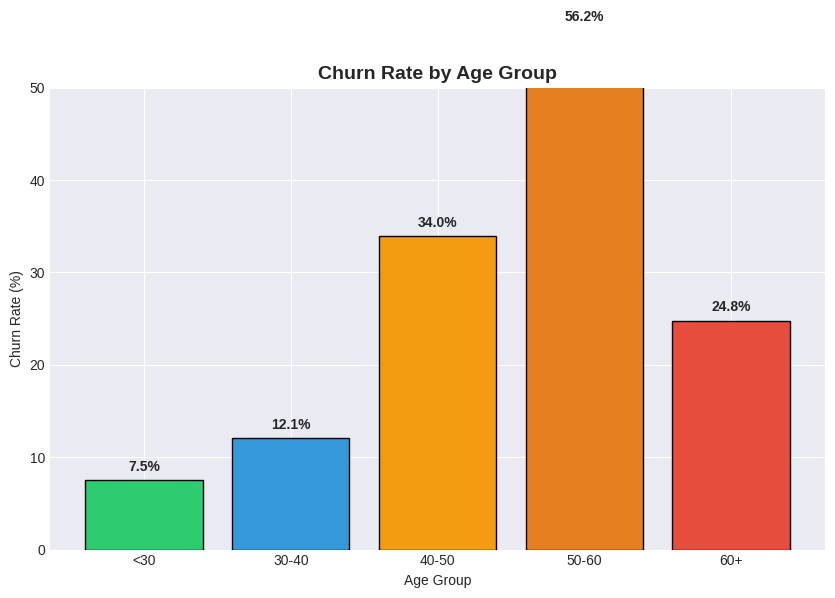


👉 Highest churn age group: 50-60 (56.2%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('/content/Churn_Modelling.csv')

# Drop unnecessary columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Create age groups
df['Age_group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])

# PLOT 3: Age vs Churn
plt.figure(figsize=(10, 6))

# Calculate churn rate for each age group
age_churn_rates = []
age_groups = ['<30', '30-40', '40-50', '50-60', '60+']

for age_group in age_groups:
    group_data = df[df['Age_group'] == age_group]
    churn_rate = group_data['Exited'].mean() * 100
    age_churn_rates.append(churn_rate)
    print(f"{age_group}: {churn_rate:.1f}% churn rate ({len(group_data)} customers)")

# Create bar chart
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar(age_groups, age_churn_rates, color=colors, edgecolor='black')
plt.title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

plt.show()

# Find highest churn age group
max_churn_age = age_groups[np.argmax(age_churn_rates)]
print(f"\n👉 Highest churn age group: {max_churn_age} ({max(age_churn_rates):.1f}%)")

In [ ]:
# Saving the model
model.save('churn_prediction_model.h5')

# Saving the scaler too (we'll need it for new predictions)
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
import tensorflow as tf
import joblib
import numpy as np
import IPython
from google.colab import output

# 1. Load the model and scaler once so it's fast
print("Loading model and scaler...")
try:
    model = tf.keras.models.load_model('churn_prediction_model.h5')
    scaler = joblib.load('scaler.pkl')
    print("Assets loaded successfully!")
except Exception as e:
    print(f"Error loading assets: {e}. Make sure the files are in the current directory.")

# 2. Define the Python backend function
def predict_churn_from_ui(credit, age, tenure, balance, products, card, active, salary, geo, gender):
    try:
        # Preprocess categorical variables exactly how your notebook did
        geo_germany = 1 if geo == "Germany" else 0
        geo_spain = 1 if geo == "Spain" else 0
        gender_male = 1 if gender == "Male" else 0

        # Create the array in the correct feature order
        input_data = np.array([[
            float(credit), float(age), float(tenure), float(balance),
            float(products), float(card), float(active), float(salary),
            geo_germany, geo_spain, gender_male
        ]])

        # Scale and predict
        scaled_data = scaler.transform(input_data)
        prob = model.predict(scaled_data, verbose=0)[0][0]

        # Format the result
        risk = "HIGH RISK 🔴" if prob > 0.5 else "LOW RISK 🟢"
        return IPython.display.JSON({'probability': f"{prob:.2%}", 'risk': risk})

    except Exception as e:
        return IPython.display.JSON({'error': str(e)})

# Register the Python function so JavaScript can see it
output.register_callback('predict_backend', predict_churn_from_ui)

# 3. Define the HTML, CSS, and JavaScript Frontend
html_code = """
<style>
    body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f8f9fa; padding: 20px; }
    .container { max-width: 600px; margin: 0 auto; background: white; padding: 30px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
    h2 { color: #2c3e50; text-align: center; margin-bottom: 20px; }
    .form-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 15px; }
    label { font-weight: bold; color: #34495e; font-size: 14px; display: block; margin-bottom: 5px; }
    input, select { width: 100%; padding: 10px; border: 1px solid #ddd; border-radius: 5px; box-sizing: border-box; }
    button { grid-column: span 2; background-color: #3498db; color: white; border: none; padding: 12px; font-size: 16px; font-weight: bold; border-radius: 5px; cursor: pointer; margin-top: 10px; transition: background 0.3s; }
    button:hover { background-color: #2980b9; }
    #result-box { grid-column: span 2; margin-top: 20px; padding: 15px; text-align: center; font-size: 18px; font-weight: bold; border-radius: 5px; display: none; }
</style>

<div class="container">
    <h2>📊 Real-Time Churn Predictor</h2>

    <div class="form-grid">
        <div>
            <label>Credit Score</label>
            <input type="number" id="credit" value="600">
        </div>
        <div>
            <label>Age</label>
            <input type="number" id="age" value="40">
        </div>
        <div>
            <label>Tenure (Years)</label>
            <input type="number" id="tenure" value="5">
        </div>
        <div>
            <label>Balance ($)</label>
            <input type="number" id="balance" value="50000">
        </div>
        <div>
            <label>Number of Products</label>
            <select id="products">
                <option value="1">1</option><option value="2">2</option><option value="3">3</option><option value="4">4</option>
            </select>
        </div>
        <div>
            <label>Estimated Salary ($)</label>
            <input type="number" id="salary" value="60000">
        </div>
        <div>
            <label>Geography</label>
            <select id="geo">
                <option value="France">France</option><option value="Germany">Germany</option><option value="Spain">Spain</option>
            </select>
        </div>
        <div>
            <label>Gender</label>
            <select id="gender">
                <option value="Male">Male</option><option value="Female">Female</option>
            </select>
        </div>
        <div>
            <label>Has Credit Card?</label>
            <select id="card">
                <option value="1">Yes</option><option value="0">No</option>
            </select>
        </div>
        <div>
            <label>Is Active Member?</label>
            <select id="active">
                <option value="1">Yes</option><option value="0">No</option>
            </select>
        </div>

        <button onclick="makePrediction()" id="pred-btn">Predict Churn Risk</button>

        <div id="result-box"></div>
    </div>
</div>

<script>
    async function makePrediction() {
        const btn = document.getElementById('pred-btn');
        const resultBox = document.getElementById('result-box');

        btn.innerText = "Predicting...";
        btn.style.backgroundColor = "#95a5a6";

        // Gather values from the UI
        const args = [
            document.getElementById('credit').value,
            document.getElementById('age').value,
            document.getElementById('tenure').value,
            document.getElementById('balance').value,
            document.getElementById('products').value,
            document.getElementById('card').value,
            document.getElementById('active').value,
            document.getElementById('salary').value,
            document.getElementById('geo').value,
            document.getElementById('gender').value
        ];

        try {
            // Call the Python backend directly!
            const result = await google.colab.kernel.invokeFunction('predict_backend', args, {});
            const data = result.data['application/json'];

            resultBox.style.display = "block";

            if (data.error) {
                resultBox.style.backgroundColor = "#fadbd8";
                resultBox.style.color = "#c0392b";
                resultBox.innerText = "Error: " + data.error;
            } else {
                if (data.risk.includes("HIGH")) {
                    resultBox.style.backgroundColor = "#fadbd8";
                    resultBox.style.color = "#c0392b";
                } else {
                    resultBox.style.backgroundColor = "#d5f5e3";
                    resultBox.style.color = "#27ae60";
                }
                resultBox.innerText = `${data.risk} (Probability: ${data.probability})`;
            }
        } catch (err) {
            resultBox.style.display = "block";
            resultBox.innerText = "Failed to connect to backend.";
        }

        btn.innerText = "Predict Churn Risk";
        btn.style.backgroundColor = "#3498db";
    }
</script>
"""

# 4. Render the UI in the notebook
IPython.display.HTML(html_code)

Loading model and scaler...


Assets loaded successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
import pandas as pd
import json

# Load the dataset
df = pd.read_csv('/content/Churn_Modelling.csv')

# Drop columns not used by the ANN model and the target variable
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])

# Randomly sample 5 customers (you can change this number)
random_customers = df.sample(n=5).to_dict(orient='records')

# Output as formatted JSON
print(json.dumps(random_customers, indent=2))

[
  {
    "CreditScore": 486,
    "Geography": "Germany",
    "Gender": "Female",
    "Age": 40,
    "Tenure": 9,
    "Balance": 71340.09,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 76192.21
  },
  {
    "CreditScore": 656,
    "Geography": "Spain",
    "Gender": "Male",
    "Age": 26,
    "Tenure": 4,
    "Balance": 139584.57,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 36308.93
  },
  {
    "CreditScore": 802,
    "Geography": "Spain",
    "Gender": "Male",
    "Age": 38,
    "Tenure": 7,
    "Balance": 0.0,
    "NumOfProducts": 2,
    "HasCrCard": 0,
    "IsActiveMember": 1,
    "EstimatedSalary": 57764.65
  },
  {
    "CreditScore": 631,
    "Geography": "Germany",
    "Gender": "Female",
    "Age": 33,
    "Tenure": 4,
    "Balance": 123246.7,
    "NumOfProducts": 1,
    "HasCrCard": 0,
    "IsActiveMember": 0,
    "EstimatedSalary": 112687.57
  },
  {
    "CreditScore": 629,
    "Geog